In [3]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("product_info.csv")

df.head()

,user_id,timestamp,variant,device,country,traffic_source,new_user,pages_viewed,session_duration_sec,converted,order_value,revenue
0,1,2025-02-05 20:00:00,A,Desktop,India,Social,0,5,64,1,95.05,95.05
1,2,2025-06-07 04:00:00,A,Desktop,India,Social,1,9,206,0,0.00,0.00
2,3,2025-05-09 20:00:00,B,Desktop,USA,Organic,1,9,226,0,0.00,0.00
3,4,2025-01-20 10:00:00,A,Desktop,India,Organic,1,7,154,0,0.00,0.00
4,5,2025-05-24 12:00:00,A,Desktop,UK,Organic,1,4,116,0,0.00,0.00


In [5]:
## How many users are in Variant A and Variant B?

df['variant'].value_counts()

variant
B    50143
A    49857
Name: count, dtype: int64

In [21]:
## What percentage of users belong to each variant?

df['variant'].value_counts(normalize=True) * 100

variant
B    50.143
A    49.857
Name: proportion, dtype: float64

In [22]:
## What is the conversion rate for each variant?

df.groupby('variant')['converted'].mean() * 100

variant
A    11.384560
B    12.887143
Name: converted, dtype: float64

In [23]:
## Which variant has more conversions?

df.groupby('variant')['converted'].sum()

variant
A    5676
B    6462
Name: converted, dtype: int64

In [24]:
## Calculate the lift of Variant B over Variant A.

conversion = df.groupby('variant')['converted'].mean()

lift = ((conversion['B'] - conversion['A']) / conversion['A']) * 100

print(f"Lift = {lift:.2f}%")

Lift = 13.20%


In [25]:
## What is the average order value (AOV) for each variant?

df[df['converted']==1].groupby('variant')['order_value'].mean()

variant
A    75.134457
B    75.182911
Name: order_value, dtype: float64

In [31]:
## Which variant generated more total revenue?

df.groupby('variant')['revenue'].sum()

variant
A    426463.18
B    485831.97
Name: revenue, dtype: float64

In [6]:
## What is the average revenue per user?

df.groupby('variant')['revenue'].mean()

variant
A    8.553727
B    9.688929
Name: revenue, dtype: float64

In [7]:
## Compare average session duration between variants.


df.groupby('variant')['session_duration_sec'].mean()

variant
A    237.744108
B    238.100054
Name: session_duration_sec, dtype: float64

In [8]:
## Compare average pages viewed between variants.

df.groupby('variant')['pages_viewed'].mean()

variant
A    6.009106
B    6.007160
Name: pages_viewed, dtype: float64

In [9]:
## Does Variant B improve conversion for mobile users?

mobile = df[df['device']=="Mobile"]

mobile.groupby('variant')['converted'].mean()*100

variant
A    11.079988
B    12.345897
Name: converted, dtype: float64

In [10]:
## Does Variant B improve conversion for desktop users?

desktop = df[df['device']=="Desktop"]

desktop.groupby('variant')['converted'].mean()*100

variant
A    11.888864
B    13.518683
Name: converted, dtype: float64

In [11]:
## Compare conversion rates by country.

pd.crosstab(df['country'],df['variant'],values=df['converted'],aggfunc='mean')*100

variant,A,B
country,,
Australia,11.696736,13.716460
Canada,11.315046,12.938552
Germany,10.823201,13.447236
India,11.241924,12.323819
UK,11.655629,13.702043
USA,11.516123,12.613388


In [12]:
## Compare conversion rates by traffic source.

pd.crosstab(df['traffic_source'],
            df['variant'],
            values=df['converted'],
            aggfunc='mean')*100

variant,A,B
traffic_source,,
Email,13.138494,14.204395
Organic,11.004976,12.639448
Paid,11.089697,12.347440
Referral,11.475744,12.706962
Social,10.917913,13.160677


In [13]:
## Which variant performs better for new users?

new_users = df[df['new_user']==1]

new_users.groupby('variant')['converted'].mean()*100

variant
A    10.832719
B    12.356226
Name: converted, dtype: float64

In [30]:
## Is the conversion difference statistically significant? (Chi-Square Test)

table = pd.crosstab(df['variant'],df['converted'])

chi2,p,dof,expected = chi2_contingency(table)

print("P-value:",p)

P-value: 3.7218526887485873e-13


In [31]:
## Is the average session duration significantly different? (T-test)

A = df[df['variant']=="A"]['session_duration_sec']

B = df[df['variant']=="B"]['session_duration_sec']

t,p = ttest_ind(A,B)

print("P-value:",p)

P-value: 0.7391506862069301


In [29]:
## Is the average session duration significantly different? (T-test)

A = df[df['variant']=="A"]['order_value']

B = df[df['variant']=="B"]['order_value']

t,p = ttest_ind(A,B)

print(p)

2.0781475743822507e-10


In [16]:
## Is the average order value significantly different?

A = df[df['variant']=="A"]['session_duration_sec']

B = df[df['variant']=="B"]['session_duration_sec']

t,p = ttest_ind(A,B)

print("P-value:",p)

P-value: 0.7391506862069301


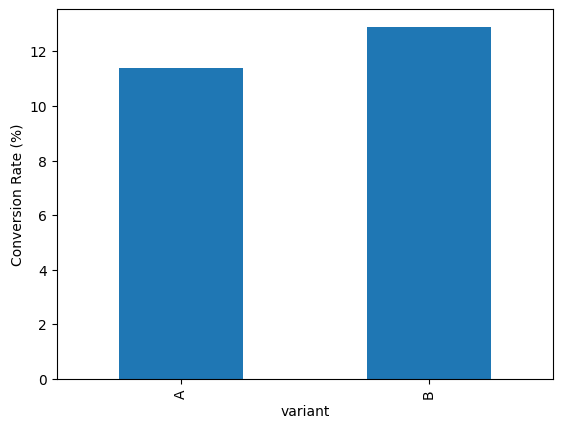

In [28]:
## Visualize conversion rates.

conversion = df.groupby('variant')['converted'].mean()*100

conversion.plot(kind='bar')

plt.ylabel("Conversion Rate (%)")

plt.show()

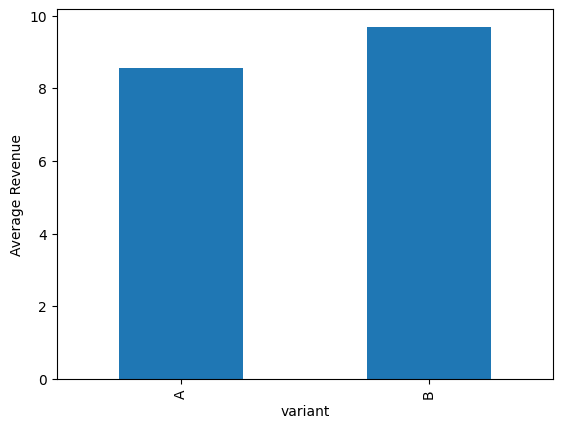

In [27]:
## Visualize average revenue.

df.groupby('variant')['revenue'].mean().plot(kind='bar')

plt.ylabel("Average Revenue")

plt.show()

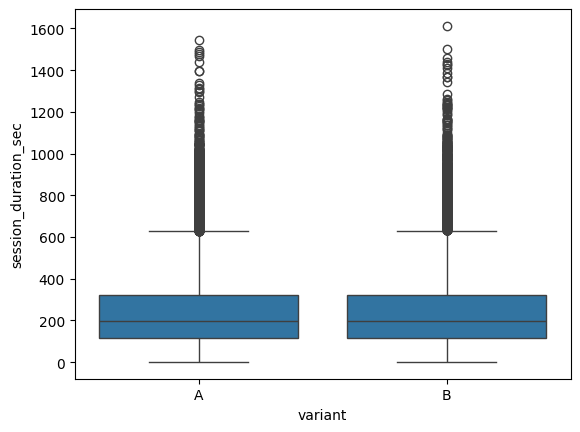

In [26]:
## Compare session duration distribution.

sns.boxplot(data=df,
            x='variant',
            y='session_duration_sec')

plt.show()

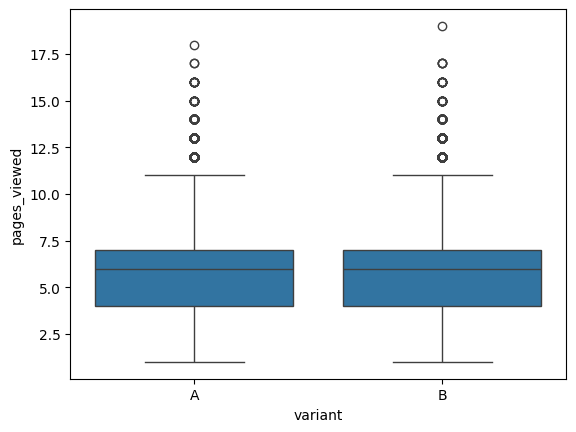

In [25]:
## Compare pages viewed distribution.

sns.boxplot(data=df,
            x='variant',
            y='pages_viewed')

plt.show()

In [24]:
## Calculate revenue uplift.

rev = df.groupby('variant')['revenue'].mean()

uplift = ((rev['B']-rev['A'])/rev['A'])*100

print(f"Revenue Lift = {uplift:.2f}%")

Revenue Lift = 13.27%


In [23]:
## Which variant should be selected?

conversion = df.groupby('variant')['converted'].mean()*100
revenue = df.groupby('variant')['revenue'].mean()

print("Conversion Rate")
print(conversion)

print("\nAverage Revenue")
print(revenue)

table = pd.crosstab(df['variant'],df['converted'])

chi2,p,dof,expected = chi2_contingency(table)

print("\nP-value:",p)

if p < 0.05:
    print("\nThe difference is statistically significant.")
else:
    print("\nNo statistically significant difference.")

Conversion Rate
variant
A    11.384560
B    12.887143
Name: converted, dtype: float64

Average Revenue
variant
A    8.553727
B    9.688929
Name: revenue, dtype: float64

P-value: 3.7218526887485873e-13

The difference is statistically significant.
